# Блок 7. Основы искусственного интеллекта и машинного обучения
## Занятие 8. Случайный лес — Random Forest

## Цель занятия

На прошлом занятии мы изучили дерево решений.

Сегодня изучаем более сильный алгоритм — **Random Forest**, или **случайный лес**.

Random Forest — это не одно дерево, а много деревьев решений, которые вместе принимают решение.

---

## Простая идея Random Forest

Одно дерево решений может ошибаться.

Но если построить много деревьев и попросить их проголосовать, итоговое решение часто становится надёжнее.

```text
Дерево 1 → класс 1
Дерево 2 → класс 1
Дерево 3 → класс 0
Дерево 4 → класс 1

Итог: класс 1
```

---

## Что такое ансамбль моделей

Ансамбль — это группа моделей, которые работают вместе.

Random Forest — пример ансамбля.

Преимущества:

- часто точнее одного дерева;
- устойчивее к переобучению;
- показывает важность признаков;
- хорошо работает на табличных данных.

---

## Что изучаем на занятии

- `RandomForestClassifier`;
- сравнение одного дерева и случайного леса;
- `n_estimators`;
- `max_depth`;
- важность признаков;
- метрики классификации;
- итоговый ML-отчёт.

---

## Датасет занятия

Используем встроенный датасет Breast Cancer из Scikit-Learn.

Задача: классифицировать объект по числовым признакам.

---

## Связь с дипломом

Random Forest можно использовать в проектах:

- HR: подходит кандидат или нет;
- медицина: риск заболевания;
- банк: надёжный или рискованный клиент;
- продажи: купит или не купит;
- маркетинг: отток клиентов;
- недвижимость: категория объекта.

---

## GitHub

```bash
git checkout main
git pull origin main
git checkout -b feature/block7-lesson08-random-forest

git add .
git commit -m "feat: add random forest lesson"
git push -u origin feature/block7-lesson08-random-forest
```


Сначала изучите SOLVED-ноутбук вместе с преподавателем. Затем выполните TODO самостоятельно.

## Ячейка 1. TODO: Импорт библиотек

### Алгоритм

Импортируйте pandas, matplotlib, датасет, модели DecisionTreeClassifier и RandomForestClassifier, а также метрики.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Библиотеки подключены")

assert pd is not None

Библиотеки подключены


## Ячейка 2. TODO: Загрузка датасета

### Алгоритм

Загрузите Breast Cancer, создайте X и y, проверьте размеры.

In [13]:
url = "../../data/daily_meal_table.csv"
df: pd.DataFrame = pd.read_csv(url)

feature_cols = ['protein_g', 'fat_g', 'carbohydrates_g', 'fiber_g', 'sugars_g', 'saturated_fat_g',
                'cholesterol_mg', 'sodium_mg', 'potassium_mg', 'water_g', ]
target_col = "is_main_meal"

df[target_col] = (df["meal"] != "breakfast").astype("int8")

print(df.shape)

assert target_col in df.columns
assert len(df) > 1000
assert df.shape[1] == 16

X = pd.DataFrame(df, columns=feature_cols)
y = pd.Series(df[target_col])
display(X.head())

print(feature_cols)

assert X.shape[1] == 10

(15322, 16)


,protein_g,fat_g,carbohydrates_g,fiber_g,sugars_g,saturated_fat_g,cholesterol_mg,sodium_mg,potassium_mg,water_g
0,16.39,17.35,102.97,9.4,28.38,2.796,16.0,954.0,165.0,50.60
1,33.00,10.00,85.40,8.2,0.00,0.555,0.0,248.0,739.0,164.80
2,15.73,10.53,22.27,1.9,3.85,1.780,28.0,536.0,128.0,84.00
3,17.68,50.74,110.79,8.2,2.00,8.091,20.0,1600.0,563.0,115.20
4,16.27,6.06,92.61,7.3,2.79,1.040,12.0,512.0,614.0,182.47


['protein_g', 'fat_g', 'carbohydrates_g', 'fiber_g', 'sugars_g', 'saturated_fat_g', 'cholesterol_mg', 'sodium_mg', 'potassium_mg', 'water_g']


## Ячейка 3. TODO: Разделение данных

### Алгоритм

Выполните train/test split с stratify=y.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

assert len(X_train) > len(X_test)

Train: (12257, 10)
Test: (3065, 10)


## Ячейка 4. TODO: Модель 1: одно дерево решений

### Алгоритм

Обучите DecisionTreeClassifier и посчитайте Accuracy.

In [15]:
tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)

assert tree_accuracy > 0.7

Decision Tree Accuracy: 0.8646003262642741


## Ячейка 5. TODO: Модель 2: Random Forest

### Алгоритм

Обучите RandomForestClassifier и посчитайте Accuracy.

In [26]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

forest_accuracy = accuracy_score(y_test, forest_pred)

print("Random Forest Accuracy:", forest_accuracy)

assert forest_accuracy > 0.8

Random Forest Accuracy: 0.8845024469820555


## Ячейка 6. TODO: Сравнение метрик

### Алгоритм

Создайте функцию calculate_metrics и таблицу сравнения моделей.

In [24]:
def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }


tree_metrics = calculate_metrics(y_test, tree_pred)
forest_metrics = calculate_metrics(y_test, forest_pred)

metrics_df = pd.DataFrame([
    {"model": "Decision Tree", **tree_metrics},
    {"model": "Random Forest", **forest_metrics}
])

display(metrics_df)

assert metrics_df.shape[0] == 2
assert "accuracy" in metrics_df.columns

,model,accuracy,precision,recall,f1
0,Decision Tree,0.864600,0.882687,0.917855,0.899928
1,Random Forest,0.884502,0.890647,0.941466,0.915352


## Ячейка 7. TODO: Важность признаков Random Forest

### Алгоритм

Получите feature_importances_ и создайте таблицу TOP признаков.

In [25]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

display(feature_importance.head(10))

assert feature_importance["importance"].sum() > 0.99

,feature,importance
5,saturated_fat_g,0.214980
9,water_g,0.147469
2,carbohydrates_g,0.114837
0,protein_g,0.107902
4,sugars_g,0.092577
6,cholesterol_mg,0.092466
1,fat_g,0.075258
7,sodium_mg,0.072069
8,potassium_mg,0.049774
3,fiber_g,0.032667


## Ячейка 8. TODO: Визуализация важности признаков

### Алгоритм

Постройте горизонтальный bar chart TOP-10 признаков.

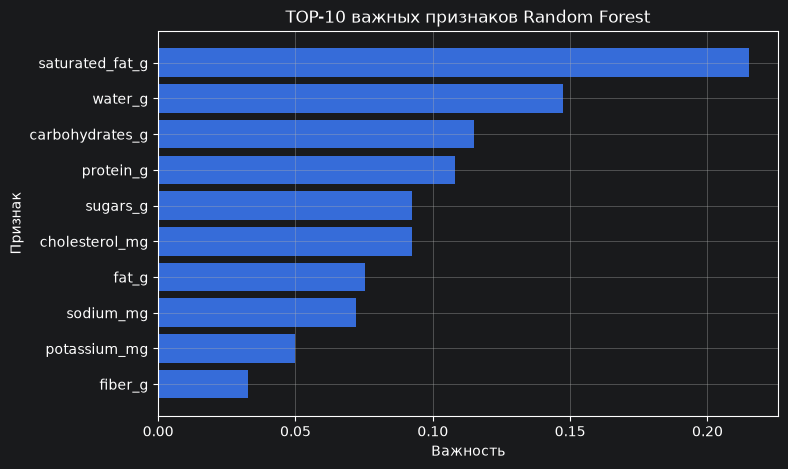

In [27]:
top_features = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("TOP-10 важных признаков Random Forest")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.grid(True)
plt.show()

assert len(top_features) == 10

## Ячейка 9. TODO: Влияние количества деревьев

### Алгоритм

Проверьте разные значения n_estimators и постройте график Accuracy.

,n_estimators,accuracy
0,5,0.854812
1,10,0.860359
2,30,0.856770
3,50,0.859380
4,100,0.856770
5,150,0.859380


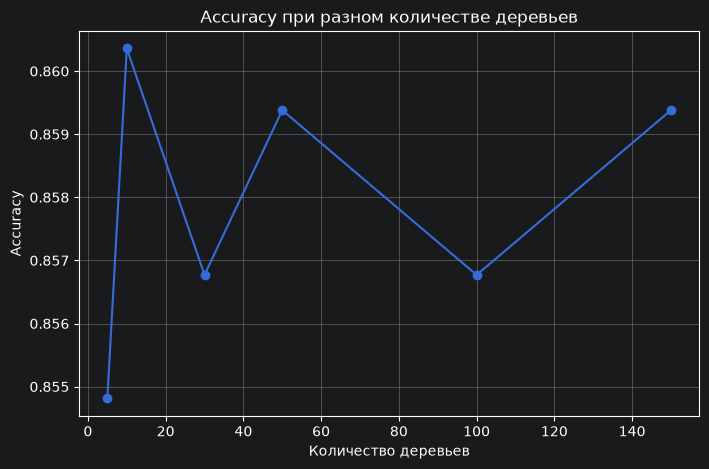

In [28]:
estimators_list = [5, 10, 30, 50, 100, 150]
scores = []

for n in estimators_list:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=5,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = accuracy_score(y_test, pred)
    scores.append(score)

results_df = pd.DataFrame({
    "n_estimators": estimators_list,
    "accuracy": scores
})

display(results_df)

plt.figure(figsize=(8, 5))
plt.plot(results_df["n_estimators"], results_df["accuracy"], marker="o")
plt.title("Accuracy при разном количестве деревьев")
plt.xlabel("Количество деревьев")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

assert len(scores) == len(estimators_list)

## Ячейка 10. TODO: Итоговый ML-отчёт

### Алгоритм

Создайте final_report, conclusions и выведите результаты.

In [31]:
best_model_name = "Random Forest" if forest_accuracy >= tree_accuracy else "Decision Tree"

final_report = {
    "rows": len(X),
    "features": X.shape[1],
    "best_model": best_model_name,
    "tree_accuracy": round(tree_accuracy, 4),
    "forest_accuracy": round(forest_accuracy, 4),
    "forest_f1": round(forest_metrics["f1"], 4),
    "top_feature": feature_importance.iloc[0]["feature"]
}

print("Итоговый отчёт:")
for key, value in final_report.items():
    print(key, ":", value)

conclusions = [
    "Random Forest объединяет несколько деревьев решений.",
    "Ансамбль часто работает устойчивее, чем одно дерево.",
    "Количество деревьев влияет на качество модели.",
    "Важность признаков помогает объяснять решения модели.",
    "Random Forest хорошо подходит для табличных данных и дипломных ML-проектов."
]

print()
print("Выводы:")
for item in conclusions:
    print("-", item)

assert final_report["features"] == 10
assert len(conclusions) == 5

Итоговый отчёт:
rows : 15322
features : 10
best_model : Random Forest
tree_accuracy : 0.8646
forest_accuracy : 0.8845
forest_f1 : 0.9154
top_feature : saturated_fat_g

Выводы:
- Random Forest объединяет несколько деревьев решений.
- Ансамбль часто работает устойчивее, чем одно дерево.
- Количество деревьев влияет на качество модели.
- Важность признаков помогает объяснять решения модели.
- Random Forest хорошо подходит для табличных данных и дипломных ML-проектов.


# Итог TODO-задания

Покажите преподавателю:

- Decision Tree;
- Random Forest;
- сравнение метрик;
- важность признаков;
- графики;
- итоговый ML-отчёт.